Nama : Jonathan William Gunawan

NIM : 2702251794

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2025-06-25 11:40:59.225742: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750851659.441768      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750851659.504273      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/ap003-air-temperature-prediction/AP003.csv


In [2]:
df = pd.read_csv("/kaggle/input/ap003-air-temperature-prediction/AP003.csv")
df.info()

# df = df.read_csv("AP003.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50400 entries, 0 to 50399
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   From Date        50400 non-null  object 
 1   To Date          50400 non-null  object 
 2   PM2.5 (ug/m3)    44691 non-null  float64
 3   PM10 (ug/m3)     45018 non-null  float64
 4   NO (ug/m3)       46252 non-null  float64
 5   NO2 (ug/m3)      45705 non-null  float64
 6   NOx (ppb)        47040 non-null  float64
 7   NH3 (ug/m3)      45756 non-null  float64
 8   SO2 (ug/m3)      43604 non-null  float64
 9   CO (mg/m3)       46993 non-null  float64
 10  Ozone (ug/m3)    45309 non-null  float64
 11  Benzene (ug/m3)  46678 non-null  float64
 12  Toluene (ug/m3)  46678 non-null  float64
 13  Temp (degree C)  46335 non-null  float64
 14  RH (%)           46520 non-null  float64
 15  WS (m/s)         46522 non-null  float64
 16  WD (degree)      44710 non-null  float64
 17  SR (W/mt2)  

In [3]:
df['From Date'] = pd.to_datetime(df['From Date'])
df['To Date'] = pd.to_datetime(df['To Date'])

## A. EDA

In [4]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
0,2017-07-01 00:00:00,2017-07-01 01:00:00,50.00,91.75,3.33,27.70,17.48,NaN,24.35,1.33,...,55.22,83.25,1.67,285.50,6.75,737.0,0.03,26.30,0.00,0.65
1,2017-07-01 01:00:00,2017-07-01 02:00:00,30.75,59.25,1.20,20.78,11.40,0.03,8.23,1.77,...,57.48,84.50,2.50,299.50,6.75,736.0,0.05,25.00,1.50,0.50
2,2017-07-01 02:00:00,2017-07-01 03:00:00,NaN,NaN,1.17,4.07,2.73,0.10,10.77,1.20,...,58.67,86.00,0.77,285.67,6.67,736.0,0.03,24.17,0.33,0.43
3,2017-07-01 03:00:00,2017-07-01 04:00:00,8.00,NaN,2.58,6.38,5.30,NaN,19.78,1.58,...,58.93,86.00,1.55,302.50,6.00,735.0,0.08,24.10,0.00,0.63
4,2017-07-01 04:00:00,2017-07-01 05:00:00,33.25,NaN,5.30,21.03,15.47,0.15,22.40,2.25,...,59.88,86.00,2.30,297.25,6.00,735.0,0.08,24.90,0.00,0.67


In [5]:
df.describe()

,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
count,50400,50400,44691.000000,45018.000000,46252.000000,45705.000000,47040.000000,45756.000000,43604.000000,46993.000000,...,46335.000000,46520.000000,46522.000000,44710.000000,47045.000000,43680.000000,47043.000000,46370.000000,47148.000000,46658.000000
mean,2020-05-15 23:30:00,2020-05-16 00:29:59.999999744,46.869591,111.938589,14.817678,34.921808,29.857413,13.813287,12.323789,0.666865,...,29.408316,73.166650,1.895205,209.078558,127.619004,746.903387,0.017120,27.591552,0.022934,2.649006
min,2017-07-01 00:00:00,2017-07-01 01:00:00,0.250000,1.000000,0.030000,0.030000,0.000000,0.020000,0.030000,0.000000,...,6.700000,15.750000,0.100000,7.000000,0.000000,700.000000,-0.550000,5.180000,0.000000,0.000000
25%,2018-12-07 23:45:00,2018-12-08 00:45:00,23.415000,63.330000,2.915000,18.400000,12.670000,7.050000,6.350000,0.330000,...,27.900000,68.000000,0.880000,157.250000,6.250000,743.000000,0.000000,24.830000,0.000000,0.570000
50%,2020-05-15 23:30:00,2020-05-16 00:30:00,38.750000,97.750000,6.600000,30.300000,22.910000,11.600000,10.680000,0.590000,...,28.850000,74.330000,1.800000,220.000000,8.250000,747.500000,0.000000,27.650000,0.000000,1.300000
75%,2021-10-22 23:15:00,2021-10-23 00:15:00,62.330000,137.500000,17.300000,43.900000,36.930000,16.770000,15.520000,0.890000,...,30.180000,79.670000,2.730000,262.670000,227.500000,751.000000,0.050000,30.400000,0.000000,2.770000
max,2023-03-31 23:00:00,2023-04-01 00:00:00,840.000000,904.000000,419.780000,420.200000,408.250000,454.900000,194.250000,11.280000,...,59.880000,92.000000,7.970000,360.000000,730.000000,770.000000,1.680000,48.500000,12.500000,410.850000
std,NaN,NaN,35.201161,74.285923,22.372042,23.912796,27.042412,14.685377,10.266289,0.550187,...,3.228845,8.592562,1.199727,67.168061,175.790733,7.656193,0.071902,4.426638,0.282441,8.785483


In [6]:
df[df.duplicated()] #Tidak ada data duplikat

,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)


In [7]:
num_cols = []

for i in df.columns:
    if "int" in str(df[i].dtype) or "float" in str(df[i].dtype):
        num_cols.append(i)
        
print(num_cols)

['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)', 'Temp (degree C)', 'RH (%)', 'WS (m/s)', 'WD (degree)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'AT (degree C)', 'RF (mm)', 'Xylene (ug/m3)']


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


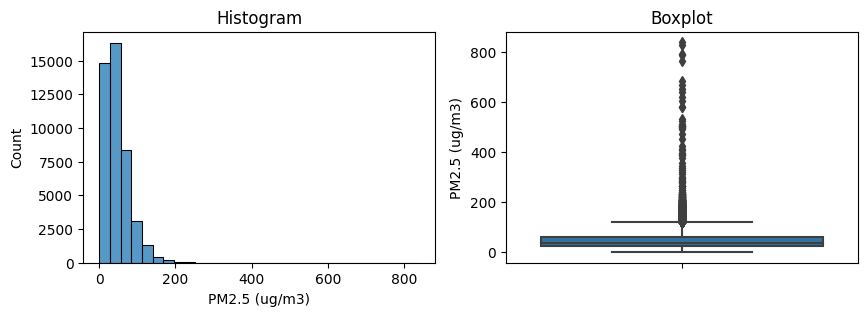

Skewness: 3.8120308404033287
Kurtosis: 48.48340018970148


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


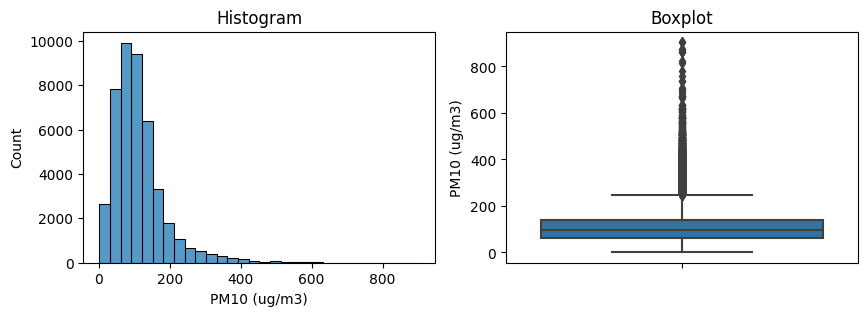

Skewness: 2.1486766161738498
Kurtosis: 8.227009584889005


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


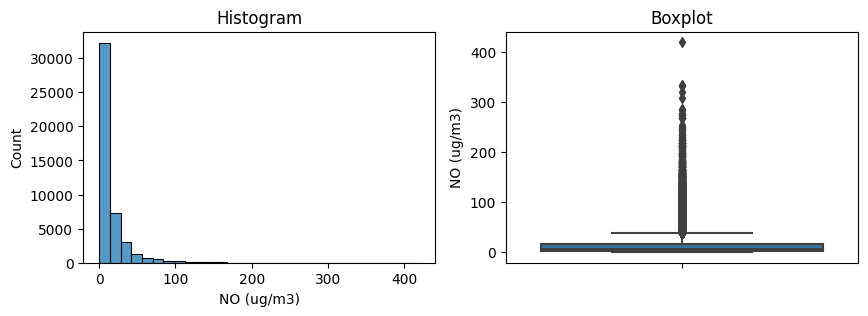

Skewness: 4.012152541960517
Kurtosis: 25.318125011144698


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


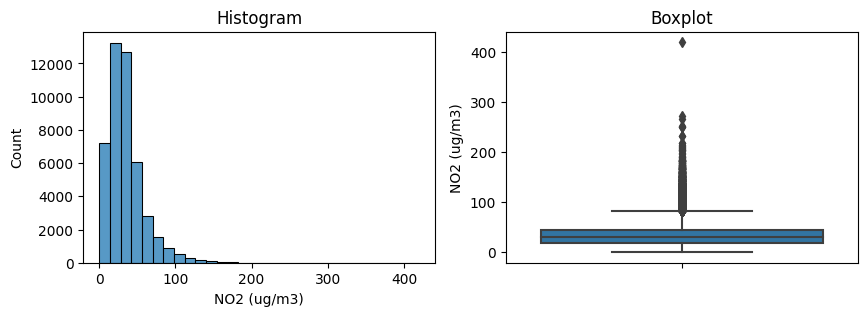

Skewness: 1.9272655048017187
Kurtosis: 7.248969095628032


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


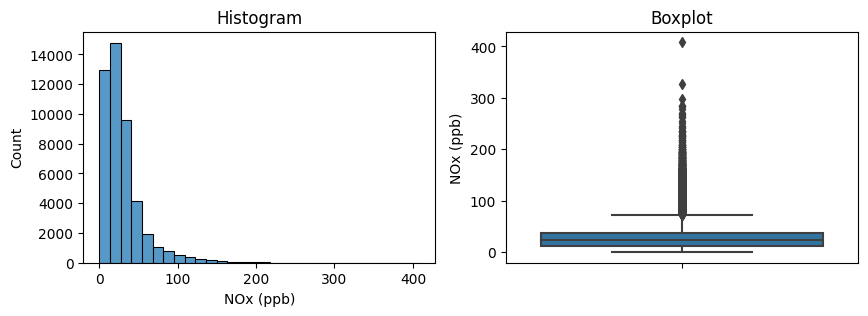

Skewness: 2.5908837540692926
Kurtosis: 10.443009518551193


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


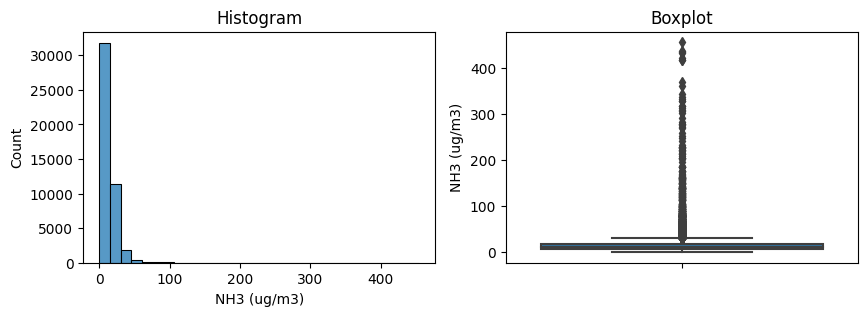

Skewness: 10.59101626836152
Kurtosis: 208.47970573564945


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


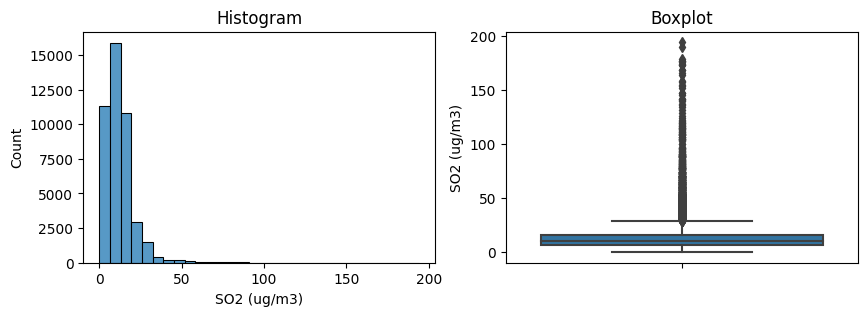

Skewness: 4.648163051137526
Kurtosis: 45.213892212912945


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


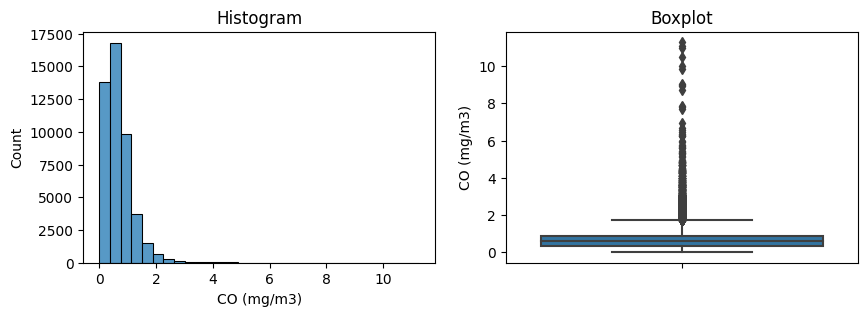

Skewness: 3.086232178353526
Kurtosis: 28.728343935521586


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


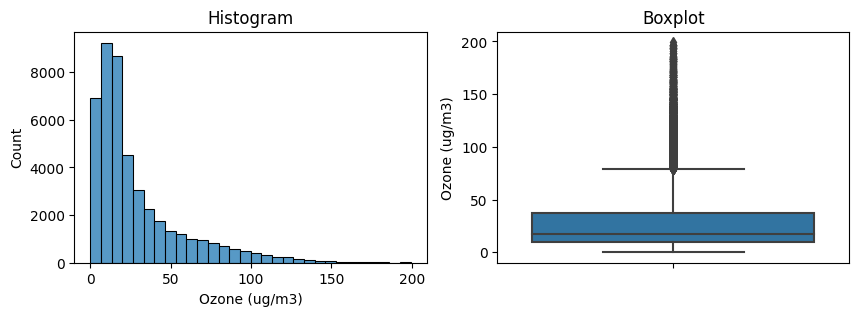

Skewness: 1.8824009979882446
Kurtosis: 3.7433378247036684


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


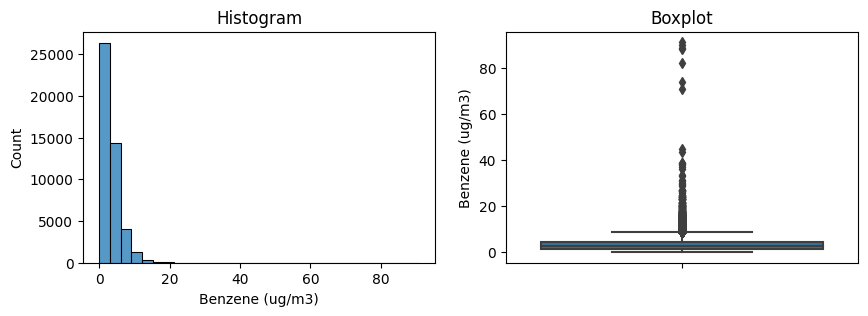

Skewness: 5.031570891167828
Kurtosis: 97.29771288713906


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


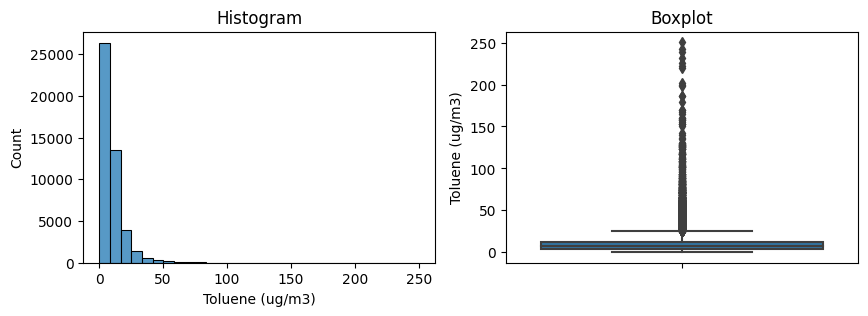

Skewness: 5.322849779426199
Kurtosis: 59.38415219840315


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


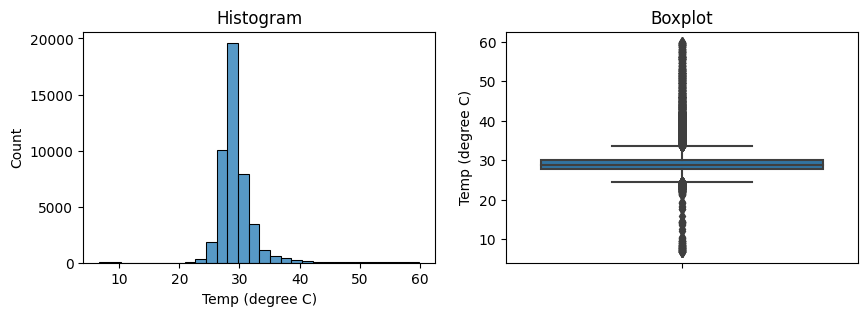

Skewness: 2.8674251310339884
Kurtosis: 22.397830074999778


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


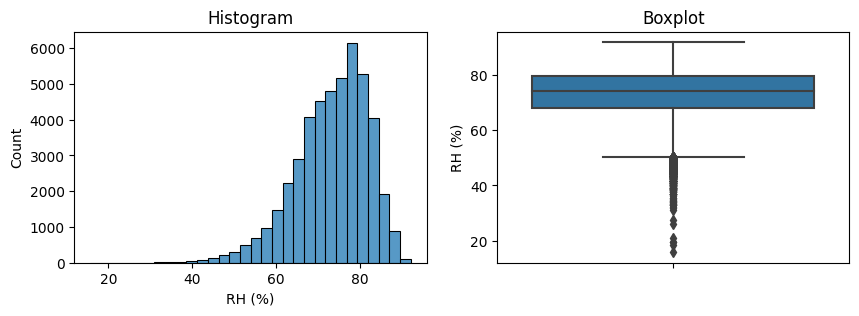

Skewness: -0.7675688099948291
Kurtosis: 0.7524505862734303


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


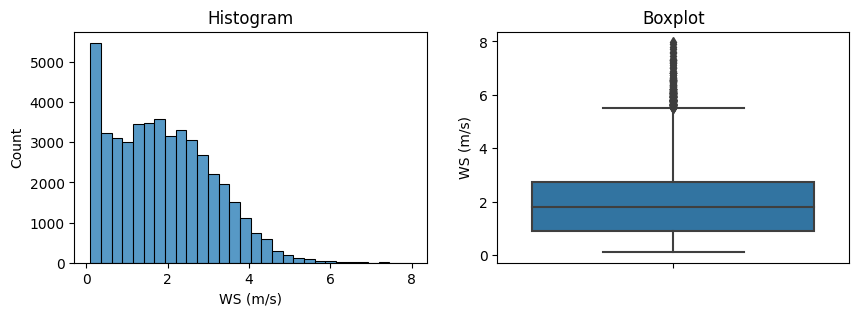

Skewness: 0.557039975001551
Kurtosis: -0.13684202119521505


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


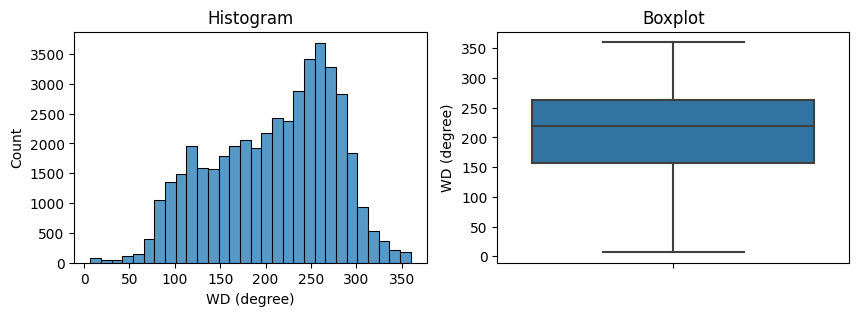

Skewness: -0.34911852741540333
Kurtosis: -0.7480644274386905


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


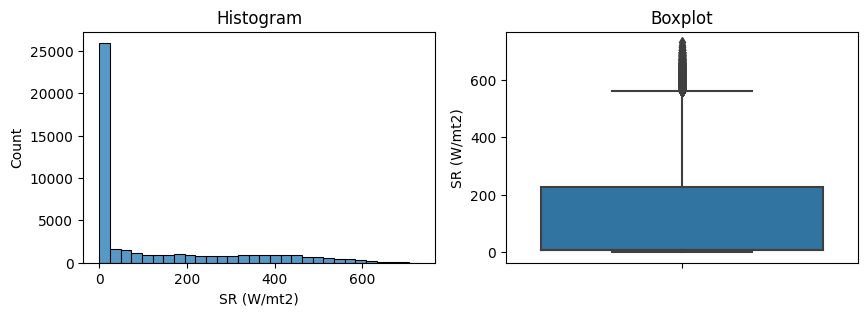

Skewness: 1.2658550457078355
Kurtosis: 0.30004033150502085


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


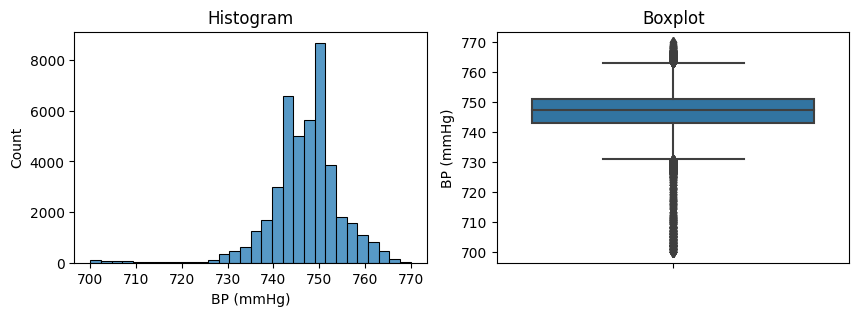

Skewness: -1.2407614524936506
Kurtosis: 6.11967758495874


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


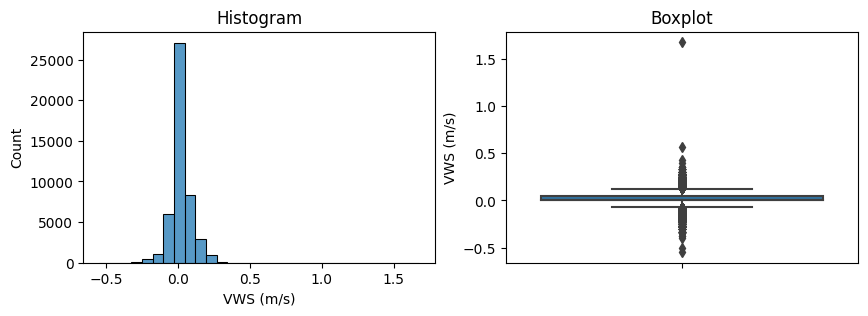

Skewness: 0.36516854095996243
Kurtosis: 8.734654849669557


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


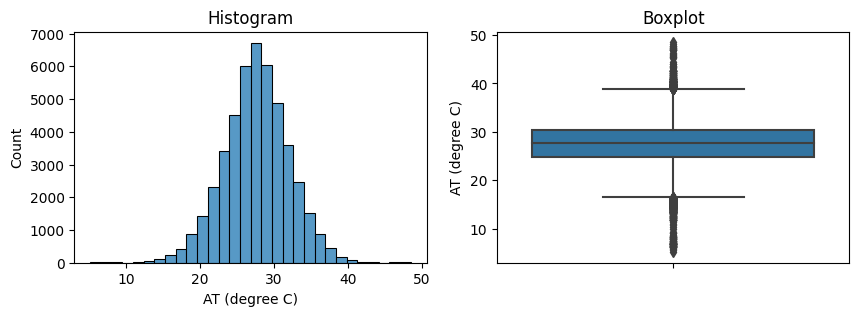

Skewness: -0.14990869659051165
Kurtosis: 0.7565053084001261


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


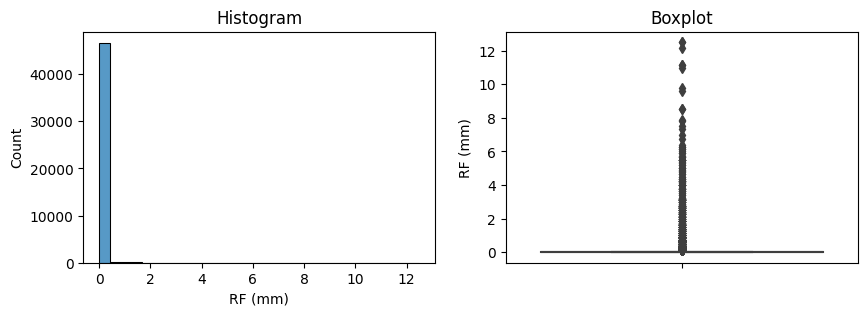

Skewness: 22.378910166308625
Kurtosis: 662.5156496274641


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


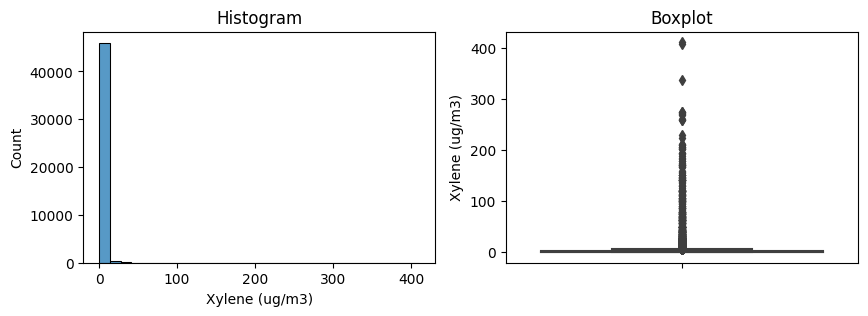

Skewness: 20.243137661715526
Kurtosis: 563.4928163023169


In [8]:
def check_distribution_outliers(df, columns):
    for col in columns:
        plt.figure(figsize=(10, 3))

        # Histogram
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], bins=30)
        plt.title('Histogram')

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(y=df[col])
        plt.title('Boxplot')

        plt.show()

        print('Skewness:', df[col].skew())
        print('Kurtosis:', df[col].kurt())

check_distribution_outliers(df[num_cols], num_cols)

Dapat dilihat datanya memiliki banyak outlier dan sangat skewed.

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


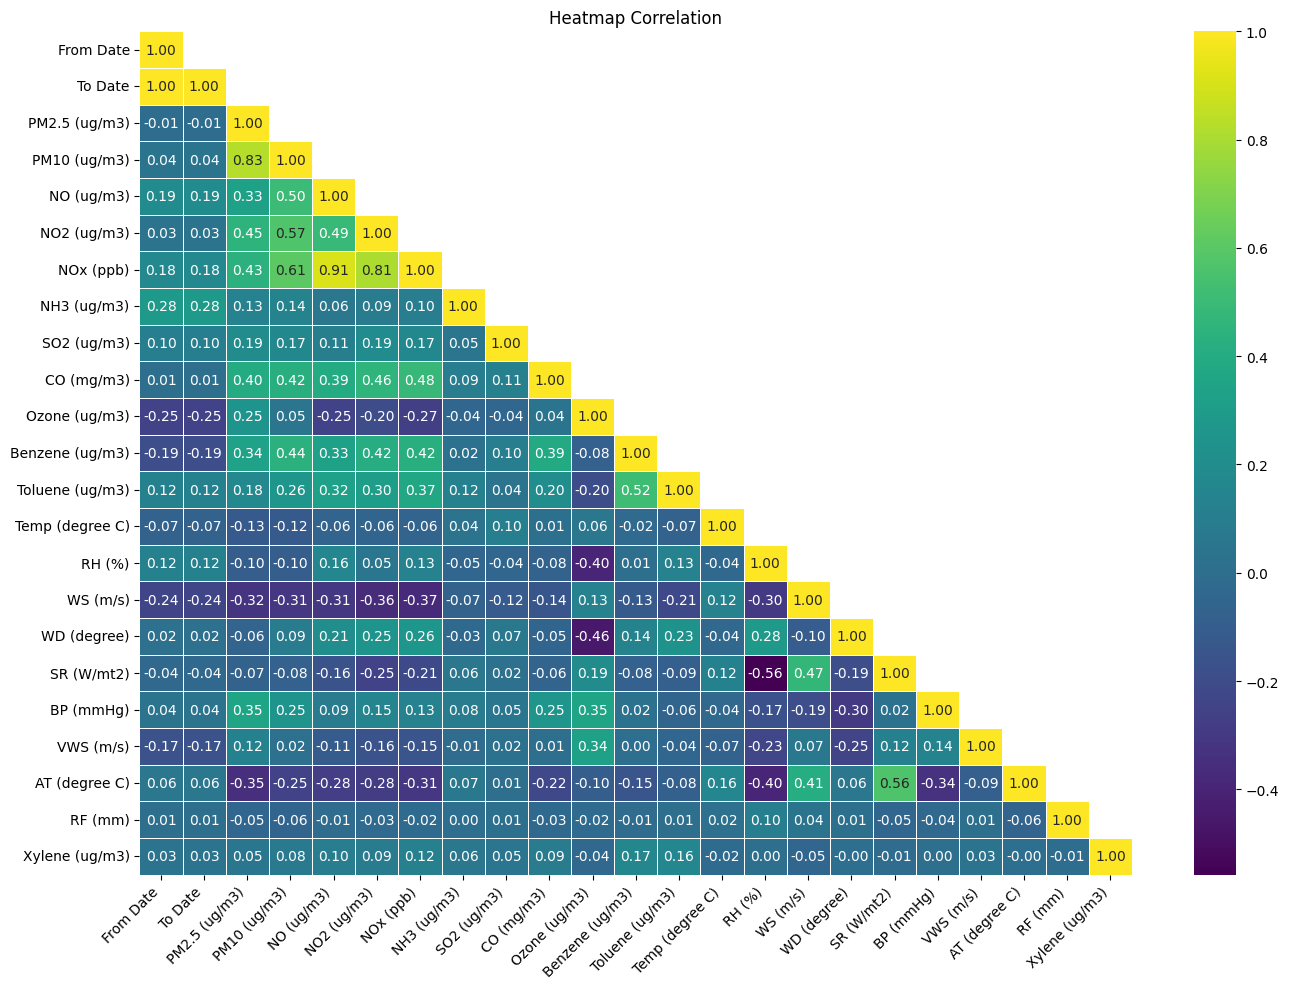

In [12]:
import seaborn as sns
corr_matrix = df.corr()

corr_lower = corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=0).astype(bool))

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    data=corr_lower,
    annot=True,            
    fmt='.2f',             
    cmap='viridis',
    linewidths=0.5,        
    linecolor='white',
    annot_kws={"size": 10}
)

plt.title('Heatmap Correlation')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
df.isnull().sum()

From Date             0
To Date               0
PM2.5 (ug/m3)      5709
PM10 (ug/m3)       5382
NO (ug/m3)         4148
NO2 (ug/m3)        4695
NOx (ppb)          3360
NH3 (ug/m3)        4644
SO2 (ug/m3)        6796
CO (mg/m3)         3407
Ozone (ug/m3)      5091
Benzene (ug/m3)    3722
Toluene (ug/m3)    3722
Temp (degree C)    4065
RH (%)             3880
WS (m/s)           3878
WD (degree)        5690
SR (W/mt2)         3355
BP (mmHg)          6720
VWS (m/s)          3357
AT (degree C)      4030
RF (mm)            3252
Xylene (ug/m3)     3742
dtype: int64

In [11]:
df.loc[df['AT (degree C)'].isnull()]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
61,2017-07-03 13:00:00,2017-07-03 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226,2017-07-10 10:00:00,2017-07-10 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
863,2017-08-05 23:00:00,2017-08-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
864,2017-08-06 00:00:00,2017-08-06 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
865,2017-08-06 01:00:00,2017-08-06 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50394,2023-03-31 18:00:00,2023-03-31 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50395,2023-03-31 19:00:00,2023-03-31 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50396,2023-03-31 20:00:00,2023-03-31 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50397,2023-03-31 21:00:00,2023-03-31 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
col = df.select_dtypes(include='float64').columns
df[df[col].isnull().all(axis=1)]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
61,2017-07-03 13:00:00,2017-07-03 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226,2017-07-10 10:00:00,2017-07-10 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
863,2017-08-05 23:00:00,2017-08-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
864,2017-08-06 00:00:00,2017-08-06 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
865,2017-08-06 01:00:00,2017-08-06 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50394,2023-03-31 18:00:00,2023-03-31 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50395,2023-03-31 19:00:00,2023-03-31 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50396,2023-03-31 20:00:00,2023-03-31 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50397,2023-03-31 21:00:00,2023-03-31 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
mask = df[col].isnull().all(axis=1)

# Grup berdasarkan perubahan True/False
groups = (mask != mask.shift()).cumsum()

continuous_missing = mask.groupby(groups).sum()

lengths = continuous_missing[mask.groupby(groups).first()]
print(lengths.describe())

count    292.000000
mean      11.130137
std       21.762626
min        1.000000
25%        2.000000
50%        5.000000
75%       12.000000
max      239.000000
dtype: float64


Dari sini dapat dilihat bahwa missing value berurutan paling panjang adalah 239 line. Itu artinya data kita ada hilang paling banyak selama kurang lebih 10 hari berturut turut. 

Terdapat 3250 baris yang dalam satu baris nilainya NaN semua kecuali tanggalnya. Lalu juga ada missing value yang berurutan yang paling banyak adalah 239 jam. Untuk mengatasi hal ini saya berencana untuk menghapusnya jika :
- Hanya sedikit baris yang hilang
- Pola waktunya masih utuh

Jika pola waktunya berubah maka saya akan ganti dengan interpolasi. Meskipun datanya akan noise tetapi dengan interpolasi timelinenya akan tetap lengkap dan cara ini sederhana.

In [14]:
original_timeline = pd.DatetimeIndex(df['From Date'].sort_values())
df_clean = df[~mask]
cleaned_timeline = pd.DatetimeIndex(df_clean['From Date'].sort_values())

missing_times = original_timeline.difference(cleaned_timeline)

print(f"Ada {len(missing_times)} waktu yang hilang setelah hapus baris")
print(missing_times[:10]) 

Ada 3250 waktu yang hilang setelah hapus baris
DatetimeIndex(['2017-07-03 13:00:00', '2017-07-10 10:00:00',
               '2017-08-05 23:00:00', '2017-08-06 00:00:00',
               '2017-08-06 01:00:00', '2017-09-01 07:00:00',
               '2017-09-02 06:00:00', '2017-09-02 07:00:00',
               '2017-09-02 08:00:00', '2017-09-04 10:00:00'],
              dtype='datetime64[ns]', name='From Date', freq=None)


Karena ada waktu yang hilang setelah hapus baris, maka saya akan input menggunakan interpolasi berdasarkan waktu

In [15]:
# df['Time Range'] = df['From Date'].dt.strftime('%Y-%m-%d %H:%M:%S') + ' - ' + df['To Date'].dt.strftime('%H:%M:%S')

In [16]:
interpolate_df = df.copy()
interpolate_df = interpolate_df.set_index('To Date')
interpolate_df = interpolate_df.drop('From Date', axis=1)
# interpolate_df.info()

# Interpolasi dan imputasi
interpolate_df = interpolate_df.interpolate(method='time', limit_direction='both')

interpolate_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50400 entries, 2017-07-01 01:00:00 to 2023-04-01 00:00:00
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PM2.5 (ug/m3)    50400 non-null  float64
 1   PM10 (ug/m3)     50400 non-null  float64
 2   NO (ug/m3)       50400 non-null  float64
 3   NO2 (ug/m3)      50400 non-null  float64
 4   NOx (ppb)        50400 non-null  float64
 5   NH3 (ug/m3)      50400 non-null  float64
 6   SO2 (ug/m3)      50400 non-null  float64
 7   CO (mg/m3)       50400 non-null  float64
 8   Ozone (ug/m3)    50400 non-null  float64
 9   Benzene (ug/m3)  50400 non-null  float64
 10  Toluene (ug/m3)  50400 non-null  float64
 11  Temp (degree C)  50400 non-null  float64
 12  RH (%)           50400 non-null  float64
 13  WS (m/s)         50400 non-null  float64
 14  WD (degree)      50400 non-null  float64
 15  SR (W/mt2)       50400 non-null  float64
 16  BP (mmHg)        50400 

Saya membuang kolom From Date karena menurut saya lebih penting menggunakan kolom To Date karena, nilai Air Temperature merupakan nilai saat jam di To Date

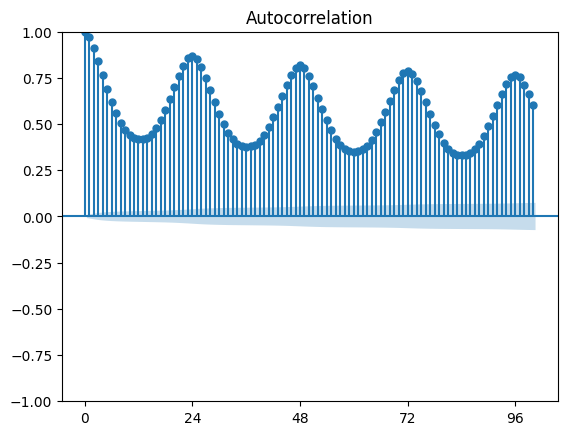

In [17]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(interpolate_df['AT (degree C)'], lags=100)
plt.xticks(np.arange(0, 101, 24))
plt.show()

Dapat dilihat bahwa, terdapat pola harian di target variabelnya dimana tiap 24 jam, dia mencapai nilai korelasi tertinggi

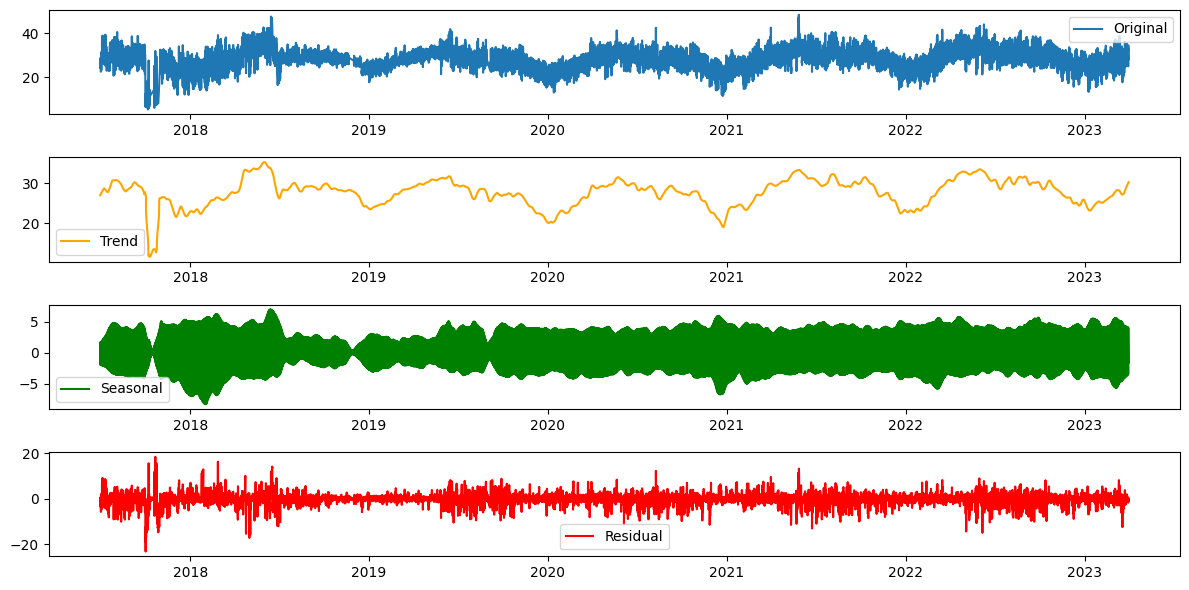

In [18]:
from statsmodels.tsa.seasonal import STL

df_hour = interpolate_df

stl = STL(df_hour['AT (degree C)'], period=24, seasonal=25, trend=365, robust=True)  
result = stl.fit()

trend = result.trend
seasonal = result.seasonal
resid = result.resid

plt.figure(figsize=(12, 6))

plt.subplot(4, 1, 1)
plt.plot(df_hour['AT (degree C)'], label='Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend', color='orange')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal', color='green')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(resid, label='Residual', color='red')
plt.legend()

plt.tight_layout()
plt.show()

Ada perubahan tren jangka panjang yang wajar, seperti penurunan dan kenaikan yang bertahap. Grafik Seasonal juga stabil, ini mendukung adanya pola harian

## B. Preprocessing

In [19]:
interpolate_df.head()

,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),Ozone (ug/m3),Benzene (ug/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
To Date,,,,,,,,,,,,,,,,,,,,,
2017-07-01 01:00:00,50.000,91.750000,3.33,27.70,17.48,0.030,24.35,1.33,144.42,0.58,...,55.22,83.25,1.67,285.50,6.75,737.0,0.03,26.30,0.00,0.65
2017-07-01 02:00:00,30.750,59.250000,1.20,20.78,11.40,0.030,8.23,1.77,144.42,0.45,...,57.48,84.50,2.50,299.50,6.75,736.0,0.05,25.00,1.50,0.50
2017-07-01 03:00:00,19.375,55.444444,1.17,4.07,2.73,0.100,10.77,1.20,144.42,0.53,...,58.67,86.00,0.77,285.67,6.67,736.0,0.03,24.17,0.33,0.43
2017-07-01 04:00:00,8.000,51.638889,2.58,6.38,5.30,0.125,19.78,1.58,144.42,0.75,...,58.93,86.00,1.55,302.50,6.00,735.0,0.08,24.10,0.00,0.63
2017-07-01 05:00:00,33.250,47.833333,5.30,21.03,15.47,0.150,22.40,2.25,42.65,0.78,...,59.88,86.00,2.30,297.25,6.00,735.0,0.08,24.90,0.00,0.67


In [20]:
cell_was_nan = df.set_index('To Date').drop('From Date', axis=1).isna()
cell_interpolated = cell_was_nan & ~interpolate_df.isna()
row_interpolated = cell_interpolated.all(axis=1).astype(int)

Ini bertujuan untuk menandai baris yang awalnya NaN lalu diimpute menggunakan interpolasi

In [21]:
target_col = 'AT (degree C)'
feature_cols = interpolate_df.columns.difference([target_col])

X = interpolate_df[feature_cols]
y = interpolate_df[target_col]

In [22]:
val_size = 0.1
test_size = 0.1

n = len(interpolate_df)
train_end = int(n * (1 - val_size - test_size))
val_end = int(n * (1 - test_size))

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

row_interp_train = row_interpolated[:train_end].values
row_interp_val   = row_interpolated[train_end:val_end].values
row_interp_test  = row_interpolated[val_end:].values

In [23]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Menggunakan RobustScaler karena RobustScaler menggunakan nilai dari Interquartile Range sehingga dia tidak sensitif terhadap outlier.

In [24]:
def has_consecutive_interpolated_rows(row_mask_window, threshold=3):
    consec = 0
    for val in row_mask_window:
        if val:
            consec += 1
            if consec >= threshold:
                return True
        else:
            consec = 0
    return False

def generate_windowed_samples(X_data, y_data, row_interpolated_mask, window_size=5, max_consec_interp_rows=3):
    Xs, ys = [], []
    for i in range(len(X_data) - window_size):
        row_window = row_interpolated_mask[i:i+window_size]
        
        if has_consecutive_interpolated_rows(row_window, threshold=max_consec_interp_rows):
            continue
        
        Xs.append(X_data[i:i+window_size])
        ys.append(y_data[i+window_size])
    return np.array(Xs), np.array(ys)

x_train, y_train = generate_windowed_samples(X_train_scaled, y_train.values, row_interp_train)
x_val, y_val     = generate_windowed_samples(X_val_scaled, y_val.values, row_interp_val)
x_test, y_test   = generate_windowed_samples(X_test_scaled, y_test.values, row_interp_test)

print(x_train.shape, y_train.shape)  
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(37463, 5, 20) (37463,)
(4925, 5, 20) (4925,)
(4893, 5, 20) (4893,)


Jadi, karena tadi data yang missing valuenya berurutan dan diinput pakai interpolasi, hasil datanya pasti noise. Untuk meghindari noise tersebut dalam model, aku membuat kalau ada lebih dari 3 baris berturut turut yang semua variabelnya diisi oleh interpolasi aku tidak akan gunakan untuk memprediksi jam berikutnya

In [25]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(x_train))  
train_ds = train_ds.batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1750845807.526878      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750845807.527640      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## C. Model

In [26]:
model = Sequential([
    LSTM(100, input_shape=(5, 21)),
    Dropout(0.2),  
    Dense(1, activation='linear')   
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100)                 │          48,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 48,901 (191.02 KB)

 Trainable params: 48,901 (191.02 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',   
    patience=5,
    restore_best_weights=True
)

In [29]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stop]  
)

Epoch 1/50


I0000 00:00:1750845811.330057      83 cuda_dnn.cc:529] Loaded cuDNN version 90300


1171/1171 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 131.1607 - mae: 7.7089 - val_loss: 10.8277 - val_mae: 2.6496
Epoch 2/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 8.5688 - mae: 2.2825 - val_loss: 6.0108 - val_mae: 1.9524
Epoch 3/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 6.8035 - mae: 2.0318 - val_loss: 8.4530 - val_mae: 2.4462
Epoch 4/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 6.2811 - mae: 1.9509 - val_loss: 6.5358 - val_mae: 2.0858
Epoch 5/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 5.8597 - mae: 1.8911 - val_loss: 7.4323 - val_mae: 2.3073
Epoch 6/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 5.6351 - mae: 1.8530 - val_loss: 5.9518 - val_mae: 2.0170
Epoch 7/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 5.2366 - mae: 1.7882 - val_loss: 7.8419 - val_mae: 2.3285
Epoch 8/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 4.9516 - mae: 1.7308 - val_loss: 4.4534 - val_mae: 1.7088
Epoch 9/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms

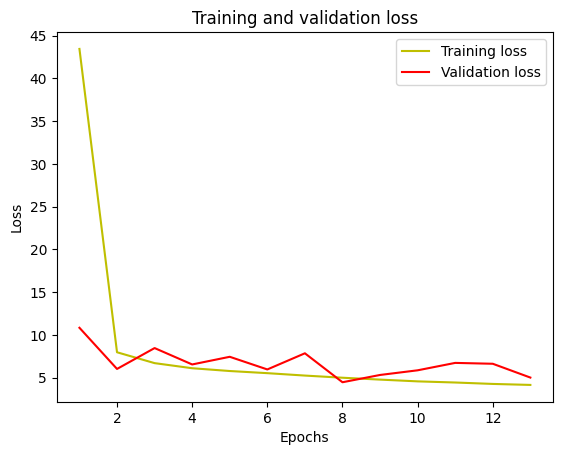

In [30]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label = 'Training loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Training loss (kuning) dan validation loss (merah) terlihat cukup sejajar dan stabil. Lalu antara training dan validationnya juga tidak ada gap yang terlalu besar sehingga tidak ada indikasi overfitting. Namun, early stopping berhenti di awal antara epoch ke-10 sampai epoch ke-16 , hal ini berarti validation loss tidak membaik. Ini menandakan model stagnan

## D. Modifikasi Model dan Hyperparameter Tuning

In [31]:
model2 = Sequential([
    LSTM(100, return_sequences=True, input_shape=(5, 21)),
    Dropout(0.2),  

    LSTM(50),
    Dropout(0.2),
    
    Dense(1, activation='linear')   
])

model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

Saya menambahkan kapasitas dari model, karena saya beranggapan model sebelumnya terlalu simple dan tidak cukup untuk menangkap kekompleksitasan dari data.

In [32]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 5, 100)              │          48,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 100)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,051 (308.79 KB)

 Trainable params: 79,051 (308.79 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model2.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stop]  
)

Epoch 1/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 165.0049 - mae: 9.9873 - val_loss: 17.3540 - val_mae: 3.2779
Epoch 2/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 11.9975 - mae: 2.6782 - val_loss: 9.1935 - val_mae: 2.5600
Epoch 3/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 8.3407 - mae: 2.2559 - val_loss: 5.2223 - val_mae: 1.7991
Epoch 4/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 7.4401 - mae: 2.1339 - val_loss: 5.7814 - val_mae: 1.9384
Epoch 5/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 6.9450 - mae: 2.0650 - val_loss: 5.8322 - val_mae: 1.9890
Epoch 6/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 6.5843 - mae: 2.0074 - val_loss: 6.6154 - val_mae: 2.1324
Epoch 7/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 6.3884 - mae: 1.9775 - val_loss: 4.8407 - val_mae: 1.7622
Epoch 8/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 5.9439 - mae: 1.9159 - val_loss: 6.1017 - val_mae: 2.0587
Epoch 9/50
1171/1171 ━━━━━━━━━━━━━━

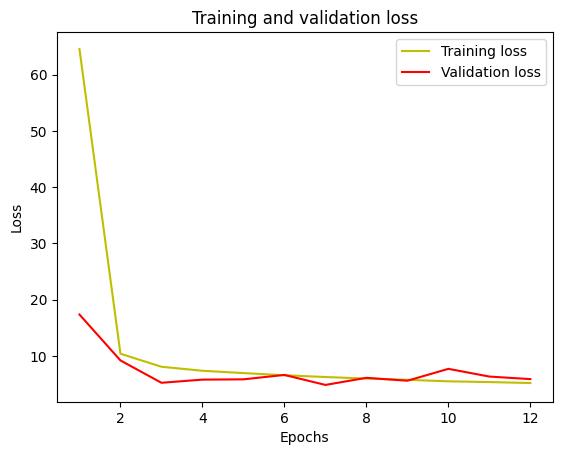

In [34]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label = 'Training loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Dapat dilihat training loss dan validation loss turun dengan stabil, tetapi dibadingkan model sebelumnya, fluktuasi validation loss lebih stabil dan gap antara trainig dan validation juga lebih kecil dan juga nilai MAE dan MSE nya juga hampir sama. Ini berarti model kedua lebih baik dalam generalization 

#### Hyperparameter Tuning

In [35]:
def build_model_seq(hp):
    model = Sequential()

    # Layer LSTM pertama
    model.add(LSTM(
        units=hp.Int('units1', min_value=10, max_value=100, step=30),
        return_sequences=True,
        input_shape=(x_train.shape[1], x_train.shape[2])
    ))
    model.add(Dropout(rate=hp.Float('dropout1', min_value=0.2, max_value=0.4, step=0.1)))

    # Layer LSTM kedua
    model.add(LSTM(
        units=hp.Int('units2', min_value=5, max_value=50, step=15)
    ))
    model.add(Dropout(rate=hp.Float('dropout2', min_value=0.2, max_value=0.4, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='linear'))

    # Optimizer + Learning rate
    lr = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2])
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model


In [36]:
from keras_tuner import Hyperband

tuner = Hyperband(
    build_model_seq,
    objective='val_loss',
    max_epochs=20,
    factor=3,
    hyperband_iterations=2,
    directory='my_dir',
    project_name='lstm_tuning_final',
    overwrite=True
)

tuner.search(train_ds,
             validation_data=val_ds,
             callbacks=[early_stop])

Trial 60 Complete [00h 01m 13s]
val_loss: 4.306302070617676

Best val_loss So Far: 4.090939044952393
Total elapsed time: 00h 49m 55s


In [41]:
best_hp = tuner.get_best_hyperparameters()[0]

best_model = tuner.hypermodel.build(best_hp)

history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)


Epoch 1/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 74.5300 - mae: 6.1215 - val_loss: 13.3104 - val_mae: 3.0115
Epoch 2/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 16.4689 - mae: 3.1999 - val_loss: 9.4432 - val_mae: 2.5581
Epoch 3/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 12.8678 - mae: 2.8224 - val_loss: 6.4056 - val_mae: 2.0481
Epoch 4/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 10.5098 - mae: 2.5530 - val_loss: 8.2966 - val_mae: 2.4243
Epoch 5/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 8.3744 - mae: 2.2544 - val_loss: 7.1048 - val_mae: 2.2032
Epoch 6/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 6.8734 - mae: 2.0353 - val_loss: 4.7549 - val_mae: 1.7205
Epoch 7/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 5.6358 - mae: 1.8365 - val_loss: 6.2795 - val_mae: 2.0585
Epoch 8/50
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 4.9770 - mae: 1.7061 - val_loss: 3.9284 - val_mae: 1.5249
Epoch 9/50
1171/1171 ━━━━━━━━━━━━━

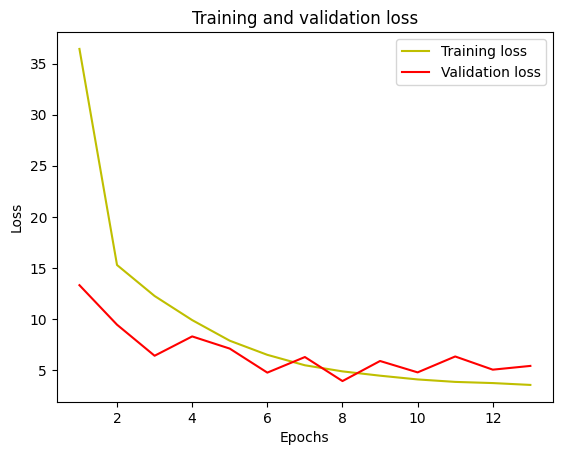

In [42]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label = 'Training loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluasi

#### Baseline Model

In [43]:
y_pred = model.predict(test_ds).flatten()

y_true = np.concatenate([y for _, y in test_ds], axis=0).flatten()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", round(mean_absolute_error(y_true, y_pred), 3))
print("MSE:", round(mean_squared_error(y_true, y_pred), 3))
print("R2 Score:", round(r2_score(y_true, y_pred), 3))

153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE: 2.372
MSE: 8.905
R2 Score: 0.464


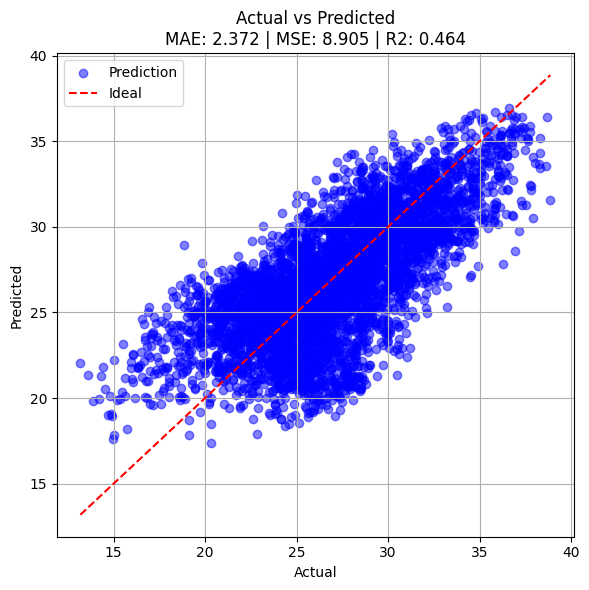

In [44]:
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
r2  = r2_score(y_true, y_pred)

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5, color='blue', label='Prediction')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title(f'Actual vs Predicted\nMAE: {mae:.3f} | MSE: {mse:.3f} | R2: {r2:.3f}')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Hyperparameter Model

In [45]:
# Evaluasi best model
y_pred_tuned = best_model.predict(test_ds).flatten()
y_true = np.concatenate([y for _, y in test_ds], axis=0).flatten()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", round(mean_absolute_error(y_true, y_pred_tuned), 3))
print("MSE:", round(mean_squared_error(y_true, y_pred_tuned), 3))
print("R2 Score:", round(r2_score(y_true, y_pred_tuned), 3))

153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MAE: 2.497
MSE: 9.906
R2 Score: 0.404


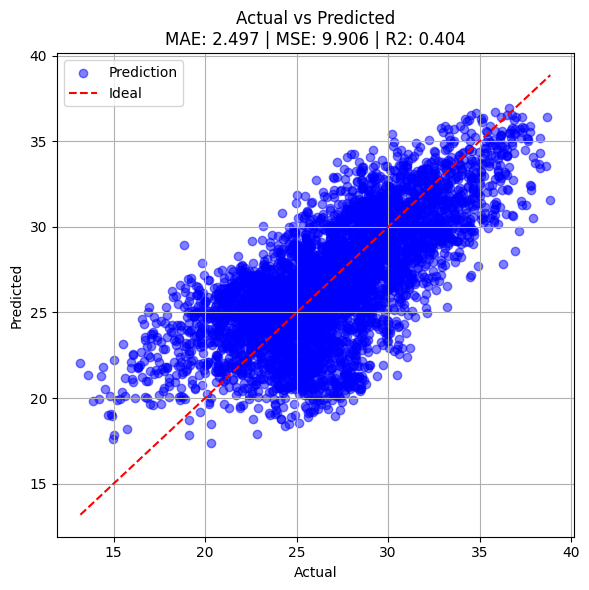

In [46]:
mae = mean_absolute_error(y_true, y_pred_tuned)
mse = mean_squared_error(y_true, y_pred_tuned)
r2  = r2_score(y_true, y_pred_tuned)

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5, color='blue', label='Prediction')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title(f'Actual vs Predicted\nMAE: {mae:.3f} | MSE: {mse:.3f} | R2: {r2:.3f}')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Kesimpulan
Berdasarkan hasil dari testing, semua nilai dari baseline model itu lebih bagus daripada model yang di hyperparameter. Ini menunjukkan bahwa model 1 yang lebih simple itu lebih sesuai dengan data yang dipunya. Dapat dilihat dari heatmap sebelumnya bahwa tidak ada korelasi yang terlalu tinggi hanya beberapa variabel saja, korelasi fitur yang rendah ini membuat model tidak perlu belajar kombinasi yang rumit 

## Pertanyaan Bonus

Dapat dilihar dari ini : 
x_train, y_train = generate_windowed_samples(X_train_scaled, y_train.values, row_interp_train)

Ya, problem ini termasuk multivariate time series, karena data disusun secara kronologis dan setiap titik waktu memiliki banyak fitur (21 fitur pada setiap window). Model belajar memprediksi target berdasarkan urutan waktu dan berbagai variabel masukan, yang merupakan ciri khas dari multivariate time series forecasting.

link video penjelasan : https://drive.google.com/file/d/1h9H6gp-T_UWSgac46VTMKXqdlH64hg70/view?usp=share_link 